# Chapter 55 — Inverse Functions

> **Prerequisites:** ch053 (Domain and Range), ch054 (Function Composition)
> 
> **You will learn:**
> - Definition of an inverse function f⁻¹
> - The condition for invertibility: bijectivity
> - How to compute inverses analytically and numerically
> - Common inverse pairs and their computational uses
> 
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

The **inverse** of a function f : A → B is a function f⁻¹ : B → A such that:
- f⁻¹(f(x)) = x for all x ∈ A (f⁻¹ undoes f)
- f(f⁻¹(y)) = y for all y ∈ B (f undoes f⁻¹)

In terms of composition: f⁻¹ ∘ f = id_A and f ∘ f⁻¹ = id_B.

**Invertibility condition:** f is invertible if and only if it is **bijective** — both injective and surjective (introduced in ch053).
- If f is not injective, two inputs map to the same output — we cannot reverse the mapping uniquely.
- If f is not surjective, some output y has no pre-image — f⁻¹(y) is undefined.

**Common inverse pairs:**
- exp and log: log(exp(x)) = x
- x² (on x≥0) and √x: √(x²) = x for x≥0
- sin (on [-π/2, π/2]) and arcsin
- addition of c and subtraction of c

**Critical note:** f⁻¹ is NOT 1/f. The superscript -1 denotes the inverse function, not the reciprocal. f⁻¹(x) ≠ 1/f(x) in general.

---

## 2. Intuition & Mental Models

**Physical analogy:** The inverse is the undo operation. Encoding and decoding are inverses. Encryption and decryption are inverses (when the key is known). Forward and backward passes in a physical process are inverses.

**Geometric interpretation:** The graph of f⁻¹ is the reflection of the graph of f across the line y = x. If (a, b) is on f's graph, then (b, a) is on f⁻¹'s graph.

**Computational analogy:** Serialization (object → bytes) and deserialization (bytes → object) are inverses. Compression and decompression are inverses. Hash functions are NOT invertible by design — they are many-to-one (not injective).

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_25056\1621539316.py:37: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


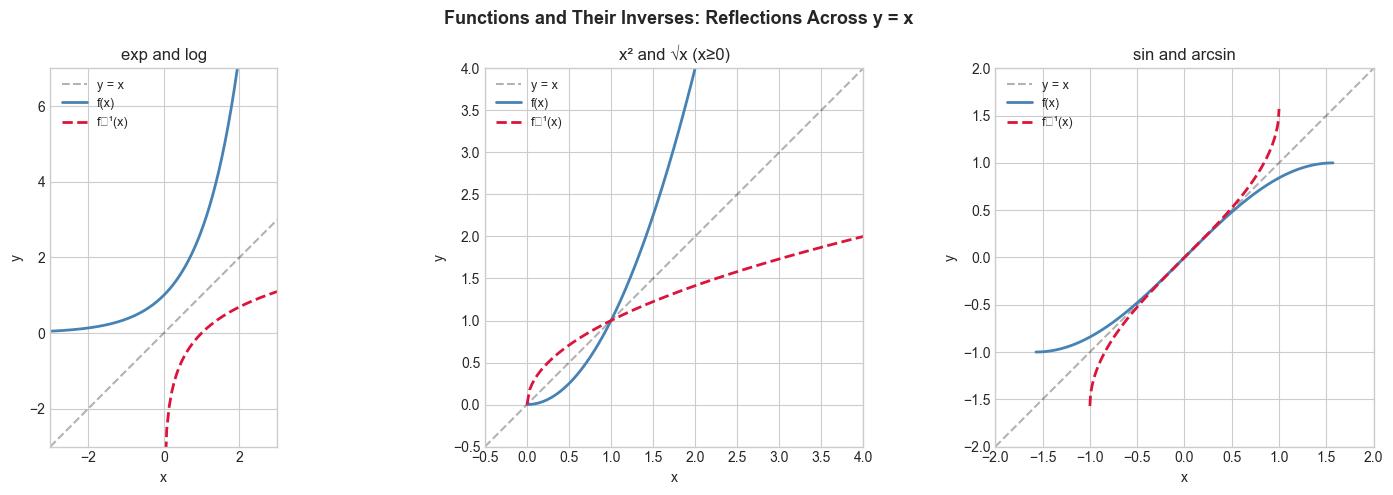

In [1]:
# --- Visualization: Functions and their inverses (reflection across y=x) ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pairs = [
    ('exp and log',
     np.linspace(-3, 3, 300), np.exp,
     np.linspace(0.01, 20, 300), np.log,
     (-3, 3), (-3, 7)),
    ('x² and √x (x≥0)',
     np.linspace(0, 3, 300), lambda x: x**2,
     np.linspace(0, 9, 300), np.sqrt,
     (-0.5, 4), (-0.5, 4)),
    ('sin and arcsin',
     np.linspace(-np.pi/2, np.pi/2, 300), np.sin,
     np.linspace(-1, 1, 300), np.arcsin,
     (-2, 2), (-2, 2)),
]

for ax, (name, x1, f1, x2, f2, xlim, ylim) in zip(axes, pairs):
    diag = np.linspace(min(xlim), max(xlim), 200)
    ax.plot(diag, diag, 'k--', alpha=0.3, label='y = x')
    ax.plot(x1, f1(x1), color='steelblue', linewidth=2, label='f(x)')
    ax.plot(x2, f2(x2), color='crimson', linewidth=2, linestyle='--', label='f⁻¹(x)')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=9)
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Functions and Their Inverses: Reflections Across y = x', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Algebraic method to find f⁻¹:** Given y = f(x), solve for x in terms of y. That gives x = f⁻¹(y).

Example: f(x) = 3x + 2
- y = 3x + 2
- y - 2 = 3x
- x = (y - 2) / 3
- So f⁻¹(y) = (y - 2) / 3

**Numerical method:** For a monotone function, the inverse can be found by interpolation — swap x and y coordinates.

In [2]:
# --- Mathematical Formulation: Numerical inverse via interpolation ---
import numpy as np

def numerical_inverse(f, domain_min, domain_max, n=10000):
    """
    Compute the numerical inverse of a monotone function f.
    Swaps x and y coordinates, then creates an interpolating function.
    
    Args:
        f: callable, strictly monotone function
        domain_min, domain_max: float, domain of f
        n: int, resolution
    Returns:
        callable: numerical approximation of f⁻¹
    """
    x = np.linspace(domain_min, domain_max, n)
    y = f(x)
    # Swap: the inverse takes y as input and returns x
    # np.interp requires sorted x — y must be monotone
    return lambda y_query: np.interp(y_query, y, x)

# Test: numerical inverse of x^3 (strictly monotone on all reals)
cube = lambda x: x**3
cbrt_numerical = numerical_inverse(cube, -10, 10)
cbrt_exact = lambda x: np.cbrt(x)

test_y = np.array([-27, -8, -1, 0, 1, 8, 27])
print("y:", test_y)
print("Numerical cbrt:", cbrt_numerical(test_y).round(4))
print("Exact cbrt:     ", cbrt_exact(test_y).round(4))

# Verify round-trip: f⁻¹(f(x)) = x
test_x = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])
roundtrip = cbrt_numerical(cube(test_x))
print("\nRound-trip check f⁻¹(f(x)) ≈ x:")
print("x:           ", test_x)
print("f⁻¹(f(x)):   ", roundtrip.round(4))

y: [-27  -8  -1   0   1   8  27]
Numerical cbrt: [-3. -2. -1.  0.  1.  2.  3.]
Exact cbrt:      [-3. -2. -1.  0.  1.  2.  3.]

Round-trip check f⁻¹(f(x)) ≈ x:
x:            [-3. -1.  0.  1.  3.]
f⁻¹(f(x)):    [-3. -1.  0.  1.  3.]


---

## 5. Python Implementation

In [3]:
# --- Implementation: Invertible transformation class ---
import numpy as np

class InvertibleTransform:
    """
    Pairs a function with its inverse, enforcing the round-trip property.
    Used in feature preprocessing where you need to undo transformations.
    """
    def __init__(self, forward, inverse, name='transform'):
        """
        Args:
            forward: callable, the function f
            inverse: callable, the function f⁻¹
            name: str, label for display
        """
        self.forward = forward
        self.inverse = inverse
        self.name = name
    
    def __call__(self, x):
        return self.forward(x)
    
    def undo(self, y):
        return self.inverse(y)
    
    def verify(self, test_values, tolerance=1e-6):
        """Verify f⁻¹(f(x)) ≈ x for test values."""
        roundtrip = self.inverse(self.forward(test_values))
        max_error = np.max(np.abs(roundtrip - test_values))
        return max_error < tolerance, max_error

# Common ML preprocessing transforms with their inverses
log_transform = InvertibleTransform(
    forward=np.log1p,   # log(1 + x) — works for x >= 0
    inverse=np.expm1,   # exp(x) - 1
    name='log1p/expm1'
)

test = np.array([0.0, 1.0, 10.0, 100.0, 1000.0])
encoded = log_transform(test)
decoded = log_transform.undo(encoded)

print("Original:  ", test)
print("Encoded:   ", encoded.round(4))
print("Decoded:   ", decoded.round(4))

ok, err = log_transform.verify(test)
print(f"Round-trip verified: {ok} (max error: {err:.2e})")

Original:   [   0.    1.   10.  100. 1000.]
Encoded:    [0.     0.6931 2.3979 4.6151 6.9088]
Decoded:    [   0.    1.   10.  100. 1000.]
Round-trip verified: True (max error: 1.14e-13)


---

## 6. Experiments

In [4]:
# --- Experiment 1: Breaking invertibility by removing injectivity ---
# Hypothesis: f(x)=x² is not invertible over all reals because it maps -2 and 2 to 4.
import numpy as np

RESTRICT_TO_POSITIVE = True  # <-- try changing to False

if RESTRICT_TO_POSITIVE:
    domain = np.linspace(0, 5, 1000)  # restricted: x >= 0
    label = "Restricted domain [0, ∞)"
else:
    domain = np.linspace(-5, 5, 1000)  # full domain: not injective!
    label = "Full domain (-∞, ∞)"

f = lambda x: x**2
y_vals = f(domain)

# Attempt numerical inverse
try:
    f_inv = lambda y_q: np.interp(y_q, y_vals, domain)
    test = np.array([0, 4, 9, 16, 25])
    inv_result = f_inv(test)
    print(f"{label}:")
    print(f"  f⁻¹([0, 4, 9, 16, 25]) = {inv_result.round(2)}")
    if not RESTRICT_TO_POSITIVE:
        print("  WARNING: Non-injective domain — inverse is ambiguous (always returns positive branch)")
except Exception as e:
    print(f"Error: {e}")

Restricted domain [0, ∞):
  f⁻¹([0, 4, 9, 16, 25]) = [0. 2. 3. 4. 5.]


---

## 7. Exercises

**Easy 1.** Find the inverse of f(x) = (5x - 3) / 2 algebraically. Verify computationally that f(f⁻¹(y)) = y for y ∈ {-5, 0, 5, 10}. *(Expected: f⁻¹(y) = (2y + 3)/5)*

**Easy 2.** Explain why f(x) = x² has no inverse over ℝ but does have an inverse if restricted to [0, ∞). What about [-∞, 0]? What would each restriction give as f⁻¹? *(Expected: two different square root functions)*

**Medium 1.** Implement the horizontal line test: given sample points (x, y) of a function, check whether any y-value is achieved by more than one x-value. This tests surjectivity. Write `horizontal_line_test(x, y, tolerance=1e-6)`. *(Hint: parallel to the vertical line test from ch051)*

**Medium 2.** Build an `InvertibleTransform` for z-score normalization: forward is `(x - mean) / std`, inverse is `z * std + mean`. Fit on a training set, then apply and undo on a test set. Verify the undo is exact. *(Hint: capture mean and std in closures)*

**Hard.** Newton's method finds x such that f(x) = y — equivalently, it computes f⁻¹(y). Implement Newton's method numerically (using finite-difference derivatives) and use it to compute f⁻¹ for f(x) = x³ + x (which has no closed-form inverse). Verify against `scipy.optimize.brentq` if available, otherwise by checking f(f⁻¹(y)) ≈ y. *(Challenge: how does convergence rate change with your initial guess?)*

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Invertible Preprocessing Pipeline ---
# Problem: In forecasting, you often transform a time series (log, normalize, etc.)
#          to make it easier to model, then invert the transformations to get
#          predictions in the original scale.
# Dataset: Simulated exponential time series (like revenue or user count).
# Task: Transform → fit trend → predict → invert → compare with actual.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Generate data: exponential growth with noise
np.random.seed(3)
n = 100
t = np.arange(n)
true_signal = 100 * np.exp(0.03 * t)
observed = true_signal * np.exp(np.random.normal(0, 0.05, n))

# Step 1: Log transform (makes exponential linear)
log_observed = np.log(observed)

# Step 2: Fit linear trend on log-transformed data (least squares)
A = np.column_stack([t, np.ones(n)])
coeffs, _, _, _ = np.linalg.lstsq(A, log_observed, rcond=None)
slope, intercept = coeffs
log_predicted = slope * t + intercept

# Step 3: Invert log transform to get predictions in original scale
predicted = np.exp(log_predicted)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t, log_observed, 'o', markersize=2, color='gray', label='log(observed)')
axes[0].plot(t, log_predicted, color='crimson', linewidth=2, label='linear fit on log scale')
axes[0].set_title('Log-Transformed Space')
axes[0].set_xlabel('t')
axes[0].set_ylabel('log(value)')
axes[0].legend()

axes[1].plot(t, observed, 'o', markersize=2, color='gray', label='observed')
axes[1].plot(t, predicted, color='steelblue', linewidth=2, label='predicted (inverted)')
axes[1].plot(t, true_signal, color='darkgreen', linewidth=1.5, linestyle='--', label='true signal')
axes[1].set_title('Original Scale (after inverting log)')
axes[1].set_xlabel('t')
axes[1].set_ylabel('value')
axes[1].legend()

plt.suptitle('Invertible Transform: Log → Fit → Invert', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Estimated growth rate: {slope:.4f} (true: 0.03)")
print(f"Estimated initial value: {np.exp(intercept):.2f} (true: 100)")

---

## 9. Chapter Summary & Connections

**What we covered:**
- f⁻¹ is the function that undoes f; defined by f⁻¹ ∘ f = id
- A function is invertible if and only if it is bijective (injective + surjective)
- f⁻¹ ≠ 1/f — notation collision to be careful of
- Numerical inversion via interpolation works for monotone functions

**Backward connection:** This completes the function composition triangle from ch054 — inverses are compositions that produce the identity.

**Forward connections:**
- In ch171 (Matrix Inverse), we will see the same concept applied to linear functions represented as matrices
- The log-transform inverse pattern in the Mini Project reappears in ch286 (Regression) where log transforms stabilize variance
- In ch251 (Bayes Theorem), conditional probability 'inverts' the direction of inference — same structural idea